In [70]:
import os
import subprocess
from pathlib import Path
from IPython import get_ipython
import re

In [71]:
!dir

 Volume in drive C has no label.
 Volume Serial Number is 5AB2-E129

 Directory of c:\tesseract-dzg

07/05/2026  09:55    <DIR>          .
07/05/2026  10:03    <DIR>          .venv
07/05/2026  10:23           203,779 eval.ipynb
06/05/2026  12:46    <DIR>          tessdata
07/05/2026  10:39    <DIR>          tesstrain
07/05/2026  10:13             3,125 test.ipynb
               2 File(s)        206,904 bytes
               4 Dir(s)  40,624,291,840 bytes free


### Get number of checkpoints

In [72]:
# Get number of checkpoints
def count_files_in_folder(folder_path):
    folder = Path(folder_path)
    if not folder.is_dir():
        raise ValueError(f"{folder_path} is not a valid directory")
    return len([f for f in folder.iterdir() if f.is_file()])

folder_path = r'C:\tesseract-dzg\tesstrain\data\dzg\tessdata_best'

counter=count_files_in_folder(folder_path)
print(f"Number of files in {folder_path}: {counter}")

Number of files in C:\tesseract-dzg\tesstrain\data\dzg\tessdata_best: 68


Automated script to evaluate each checkpoint and store error

In [73]:
#Automate the process

# Define your cell content as strings
cell_1_code = """
command = ['make', 'evaluation', 'MODEL_NAME=dzg']

output_lines=[]
# Run the command and print output in real-time
process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, encoding='utf-8')

# Print the output line by line
for line in process.stdout:
    print(line, end='')
    output_lines.append(line)

# Wait for the process to complete and get the return code
process.wait()
print(f"Process finished with return code {process.returncode}")
output = ''.join(output_lines)
"""

cell_2_code = """
pattern = r'(time[\s\S]+?)(?=make)'

match = re.search(pattern,output)

if match:
    extracted_command = match.group(0)
    print("Extracted Command:")
    print(extracted_command)

    # Path to Git Bash
    git_bash_path = "C:/Program Files/Git/bin/bash.exe"

    # Run the command using subprocess
    try:
        process = subprocess.Popen([git_bash_path, '-c', extracted_command], stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, encoding='utf-8')

        # Print the output line by line
        for line in process.stdout:
            print(line, end='')

        # Print any errors
        for line in process.stderr:
            print(line, end='')

        # Wait for the process to complete and get the return code
        process.wait()
        print(f"Process finished with return code {process.returncode}")

    except Exception as e:
        print(f"An error occurred: {e}")
else:
    print("Command not found in the output.")
"""

# Get the current IPython instance
ipython = get_ipython()

# Loop to run these cells multiple times
for i in range(counter):
    print(f"Iteration {i+1}: Running cells")
    ipython.run_cell(cell_1_code)
    ipython.run_cell(cell_2_code)

Iteration 1: Running cells
make: *** No rule to make target 'evaluation'.  Stop.
Process finished with return code 2
Command not found in the output.
Iteration 2: Running cells
make: *** No rule to make target 'evaluation'.  Stop.
Process finished with return code 2
Command not found in the output.
Iteration 3: Running cells
make: *** No rule to make target 'evaluation'.  Stop.
Process finished with return code 2
Command not found in the output.
Iteration 4: Running cells
make: *** No rule to make target 'evaluation'.  Stop.
Process finished with return code 2
Command not found in the output.
Iteration 5: Running cells
make: *** No rule to make target 'evaluation'.  Stop.
Process finished with return code 2
Command not found in the output.
Iteration 6: Running cells
make: *** No rule to make target 'evaluation'.  Stop.
Process finished with return code 2
Command not found in the output.
Iteration 7: Running cells
make: *** No rule to make target 'evaluation'.  Stop.
Process finished wi

## Training and Eval Error Plot


In [74]:
import pandas as pd
import matplotlib.pyplot as plt

In [75]:
def read_eval_error(log_folder, metric):
    iterations = []
    errors = []
    for log_file in os.listdir(log_folder):
        if log_file.endswith('.eval.log'):
            iteration = int(re.search(r'_(\d+)\.eval\.log', log_file).group(1))
            with open(os.path.join(log_folder, log_file), 'r') as file:
                for line in file:
                    regex = rf'{metric} eval=([\d.]+)'
                    match = re.search(regex, line)
                    if match:
                        iterations.append(iteration)
                        errors.append(float(match.group(1)))
                        break
    return pd.DataFrame({'Iteration': iterations, 'Eval Error': errors})

In [76]:
def read_training_error(log_file, metric):
    iterations = []
    errors = []
    with open(log_file, 'r') as file:
        for line in file:
            regex = rf'At iteration \d+/\d+/(\d+), .* {metric} train=([\d.]+)%'
            match = re.search(regex, line)
            if match:
                iterations.append(int(match.group(1)))
                errors.append(float(match.group(2)))
    return pd.DataFrame({'Iteration': iterations, 'Training Error': errors})

In [77]:
import pandas as pd
import re
import os

# --- SET YOUR PATH ---
log_file_path = "C:/tesseract-dzg/tesstrain/data/dzg/training.log"

def get_training_dataframes(log_path):
    train_list = []
    eval_list = []
    
    if not os.path.exists(log_path):
        print("Log file not found!")
        return pd.DataFrame(), pd.DataFrame()

    with open(log_path, 'r', encoding='utf-8') as f:
        for line in f:
            # Extract Training Error
            if "BCER train" in line:
                it = re.search(r'iteration (\d+)', line)
                ce = re.search(r'BCER train=(\d+\.\d+)%', line)
                if it and ce:
                    train_list.append({'Iteration': int(it.group(1)), 'Training Error': float(ce.group(1))})
            
            # Extract Eval Error (Tesseract sometimes logs this in the same file)
            if "BCER eval" in line:
                it = re.search(r'iteration (\d+)', line) # Re-check previous line or current
                ce = re.search(r'BCER eval=(\d+\.\d+)', line)
                if ce:
                    # If iteration isn't on this line, use the last known one
                    last_it = train_list[-1]['Iteration'] if train_list else 0
                    eval_list.append({'Iteration': last_it, 'Eval Error': float(ce.group(1))})

    return pd.DataFrame(train_list), pd.DataFrame(eval_list)

# Create the dataframes
training_cer, eval_cer = get_training_dataframes(log_file_path)

print(f"Training rows found: {len(training_cer)}")
print(f"Eval rows found: {len(eval_cer)}")

Training rows found: 500
Eval rows found: 5


In [87]:
if not eval_cer.empty:
    char_data = pd.merge(training_cer, eval_cer, on='Iteration', how='left').sort_values(by='Iteration')
else:
    # If no eval data, just use training data
    char_data = training_cer.copy()
    char_data['Eval Error'] = None # Add empty column so plot code doesn't crash

char_data

,Iteration,Training Error,Eval Error
0,100,35.767,NaN
1,200,33.797,NaN
2,300,35.815,NaN
3,399,35.474,NaN
4,498,35.460,NaN
...,...,...,...
495,29321,1.979,NaN
496,29349,2.097,NaN
497,29377,1.947,NaN
498,29402,1.808,NaN


In [79]:
eval_cer

,Iteration,Eval Error
0,4181,75.516
1,21234,29.005
2,23595,3.796
3,27135,3.080
4,28050,2.840


In [80]:
char_data = pd.merge(training_cer, eval_cer, on='Iteration', how='inner').sort_values(by='Iteration')
char_data

,Iteration,Training Error,Eval Error
0,4181,33.284,75.516
1,21234,3.540,29.005
2,23595,3.635,3.796
3,27135,2.323,3.080
4,28050,1.911,2.840



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\tesseract-dzg\.venv\Scripts\python.exe
['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\python311.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0', 'c:\\tesseract-dzg\\.venv', '', 'c:\\tesseract-dzg\\.venv\\Lib\\site-packages']


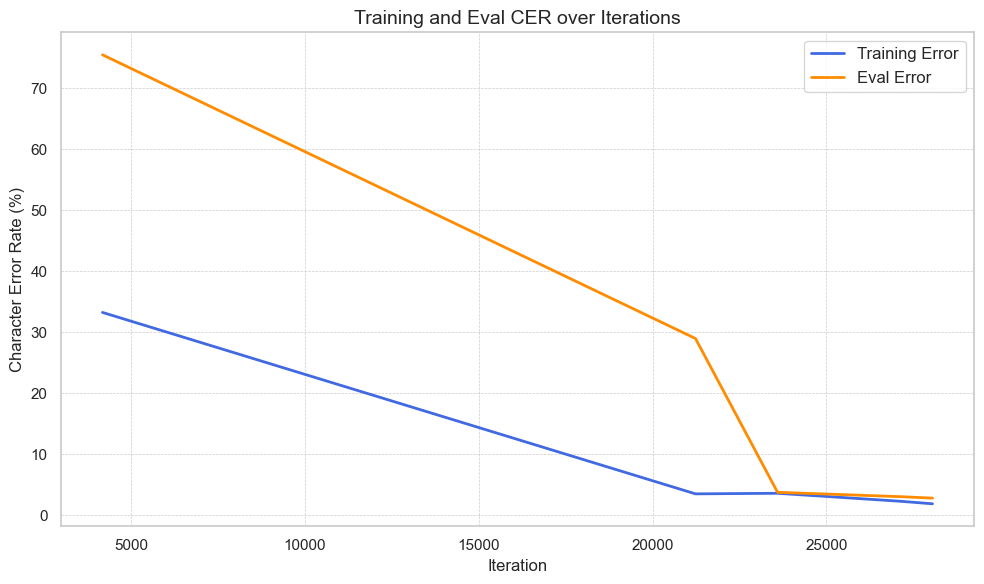

In [82]:
import sys
!"{sys.executable}" -m pip install seaborn
import seaborn as sns
import sys
print(sys.executable)
print(sys.path)
filtered_data=char_data

# Set seaborn style for a cleaner look
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(10, 6))  # Slightly wider figure for better readability

# Plot training and Eval error with thicker lines and custom colors
plt.plot(filtered_data['Iteration'], filtered_data['Training Error'], label='Training Error', color='royalblue', linewidth=2)
plt.plot(filtered_data['Iteration'], filtered_data['Eval Error'], label='Eval Error', color='darkorange', linewidth=2)

# Labels and title
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Character Error Rate (%)', fontsize=12)
plt.title('Training and Eval CER over Iterations', fontsize=14)

# Legend with improved font size
plt.legend(fontsize=12)

# Grid lines with a light touch
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Ensure a clean layout
plt.tight_layout()

# Display the plot
plt.show()

In [5]:
import pandas as pd
import re
import os

# --- SET YOUR PATH ---
log_file_path = "C:/tesseract-dzg/tesstrain/data/dzg/training.log"

def get_training_dataframes(log_path):
    train_list = []
    eval_list = []
    
    if not os.path.exists(log_path):
        print("Log file not found!")
        return pd.DataFrame(), pd.DataFrame()

    with open(log_path, 'r', encoding='utf-8') as f:
        for line in f:
            # --- Extract Training BWER ---
            if "BWER train" in line:
                it = re.search(r'iteration (\d+)', line)
                # Matches "BWER train=10.523%"
                we = re.search(r'BWER train=(\d+\.\d+)%', line)
                if it and we:
                    train_list.append({
                        'Iteration': int(it.group(1)), 
                        'Training Word Error': float(we.group(1))
                    })
            
            # --- Extract Eval BWER ---
            if "BWER eval" in line:
                it = re.search(r'iteration (\d+)', line)
                we = re.search(r'BWER eval=(\d+\.\d+)%', line)
                if we:
                    # If iteration isn't on the eval line, use the last training iteration
                    last_it = train_list[-1]['Iteration'] if train_list else 0
                    eval_list.append({
                        'Iteration': last_it, 
                        'Eval Word Error': float(we.group(1))
                    })

    return pd.DataFrame(train_list), pd.DataFrame(eval_list)

# Create the dataframes
training_wer, eval_wer = get_training_dataframes(log_file_path)

print(f"Training (WER) rows found: {len(training_wer)}")
print(f"Eval (WER) rows found: {len(eval_wer)}")

# Optional: View the first few rows
if not training_wer.empty:
    print(training_wer.head())
    
training_wer



Training (WER) rows found: 500
Eval (WER) rows found: 0
   Iteration  Training Word Error
0        100               87.455
1        200               86.607
2        300               87.794
3        399               87.358
4        498               87.173


,Iteration,Training Word Error
0,100,87.455
1,200,86.607
2,300,87.794
3,399,87.358
4,498,87.173
...,...,...
495,29321,18.735
496,29349,19.472
497,29377,19.498
498,29402,19.010


In [29]:
import sys
!"{sys.executable}" -m pip install pytesseract
from PIL import Image
import pytesseract

import sys
print(sys.executable)
print(sys.path[:3])

image= Image.open(r"C:\tesseract-dzg\tesstrain\data\dzg-ground-truth\dzo_Wangdi29_456.tif")
text=pytesseract.image_to_string(image,lang='dzo')
print(text)


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\tesseract-dzg\.venv\Scripts\python.exe
['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\python311.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib']
ཐོགརར་འབད་མ་རོད་ནང་ལུ་འོག་ཚོག་ལུ་འབྲུ་མངོད།



In [30]:
import sys
!"{sys.executable}" -m pip install pytesseract
from PIL import Image
import pytesseract

import sys
print(sys.executable)
print(sys.path[:3])

image= Image.open(r"C:\tesseract-dzg\tesstrain\data\dzg-ground-truth\dzo_Wangdi29_456.tif")
text=pytesseract.image_to_string(image,lang='dzg')
print(text)

c:\tesseract-dzg\.venv\Scripts\python.exe
['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\python311.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib']
ཐོག་ར་འབད་མི་རྫོང་ནང་ལུ་འོག་ཐོག་ལུ་འབྱུ་མཛོད།




[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import pandas as pd
import re
import os

# --- SET YOUR PATH ---
log_file_path = "C:/tesseract-dzg/tesstrain/data/dzg/training.log"

def get_training_dataframes(log_path):
    train_list = []
    eval_list = []
    
    if not os.path.exists(log_path):
        print("Log file not found!")
        return pd.DataFrame(), pd.DataFrame()

    with open(log_path, 'r', encoding='utf-8') as f:
        for line in f:
            # --- Extract Training BWER ---
            if "BWER train" in line:
                it = re.search(r'iteration (\d+)', line)
                # Matches "BWER train=10.523%"
                we = re.search(r'BWER train=(\d+\.\d+)%', line)
                if it and we:
                    train_list.append({
                        'Iteration': int(it.group(1)), 
                        'Training Word Error': float(we.group(1))
                    })
            
            # --- Extract Eval BWER ---
            if "BWER eval" in line:
                it = re.search(r'iteration (\d+)', line)
                we = re.search(r'BWER eval=(\d+\.\d+)%', line)
                if we:
                    # If iteration isn't on the eval line, use the last training iteration
                    last_it = train_list[-1]['Iteration'] if train_list else 0
                    eval_list.append({
                        'Iteration': last_it, 
                        'Eval Word Error': float(we.group(1))
                    })

    return pd.DataFrame(train_list), pd.DataFrame(eval_list)

# Create the dataframes
training_wer, eval_wer = get_training_dataframes(log_file_path)

print(f"Training (WER) rows found: {len(training_wer)}")
print(f"Eval (WER) rows found: {len(eval_wer)}")

# Optional: View the first few rows
if not training_wer.empty:
    print(training_wer.head())

Training (WER) rows found: 500
Eval (WER) rows found: 0
   Iteration  Training Word Error
0        100               87.455
1        200               86.607
2        300               87.794
3        399               87.358
4        498               87.173


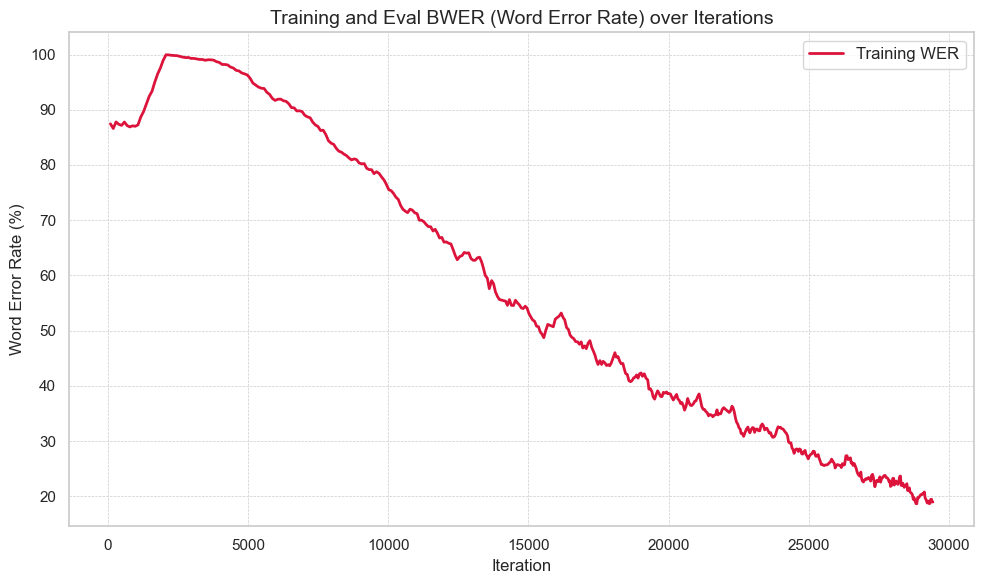

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Plot Training BWER
if not training_wer.empty:
    plt.plot(training_wer['Iteration'], training_wer['Training Word Error'], 
             label='Training WER', color='crimson', linewidth=2)

# Plot Eval BWER
if not eval_wer.empty:
    plt.plot(eval_wer['Iteration'], eval_wer['Eval Word Error'], 
             label='Eval WER', color='teal', linewidth=2, linestyle='--')

# Labels and title
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Word Error Rate (%)', fontsize=12)
plt.title('Training and Eval BWER (Word Error Rate) over Iterations', fontsize=14)

plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.show()